In [1]:
n = 675
number_of_topics = 18
n_clusters = 16
clustering_method = "minibatch"
trained_topic_model_folder = "Subphenotyping-for-PASC_test/trained_topic_model_emory_sinai_v1"
print(f'results_emory_sinai_n{n}_{number_of_topics}topics_{n_clusters}clusters_v{trained_topic_model_folder.split("_v")[-1]}')

results_emory_sinai_n675_18topics_16clusters_v1


In [2]:
import numpy as np
import pandas as pd
import re
import os
import scipy.io as sio
import openpyxl
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

import sklearn.cluster
from sklearn import preprocessing
import umap

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import plotly.express as px
import plotly.graph_objects as go

In [3]:
file = f'{trained_topic_model_folder}/PFA_trained_model_n{n}_k{number_of_topics}.mat'
data = sio.loadmat(file) 
print(file)

surveys = pd.read_csv("data_cleaned/emory_and_sinai_n675.csv")

colors = list(sns.color_palette("tab20"))
colors.extend(["purple", "black", "yellow", "green", "blue", "pink", "cyan", "cyan", "cyan"])

file_ = open('references/symptoms_sinai.txt','r')
symptoms = file_.readlines()[:44]
file_.close()
symptoms = [val.lower().replace("\n", "") for val in symptoms]
print(len(symptoms), "symptoms")
columns = list(filter(re.compile("currentsymptoms_.*").match, surveys.columns))
columns = [int(val.split("_")[-1]) for val in columns]
symptoms = [symptoms[i-1] for i in columns]

file_ = open('references/Neurological_Symptom_Mapping.txt','r')
mapping = [val.lower().replace("\n", "").replace("\t", "") for val in file_.readlines()]
file_.close()
neurologicals = [val.lower() for val in ["Neurological", "Cognitive/Psych", "Musculo-Skeletal", "G.I", "Sexual/Hormonal Function", "sensory changes", "temperature regulation", "pulmonary", "cardiovascular"]]
neurological_symptom_mapping, color_mapping, symptoms_ordered, symptoms_ordered_colors = {}, {}, [], []
curr, ct = "", -1
for val in mapping: 
    val = val.replace("\t", "")
    if val in neurologicals: 
        curr = val
        ct += 1
    else: 
        if val not in symptoms: 
            if val == "abnormal changes in body temp": val = "Abnormal changes in body temperature".lower()
            elif val == "unexplained sweats or flushin": val = "Unexplained sweats or flushing".lower()
            else: continue
        symptoms_ordered.append(val)
        symptoms_ordered_colors.append(colors[ct])
        color_mapping[curr] = colors[ct]
        if curr not in list(neurological_symptom_mapping.keys()): neurological_symptom_mapping[curr] = [val]
        else: neurological_symptom_mapping[curr].append(val)
print(len(neurological_symptom_mapping.keys()),  "symptom groups")

# comorb_selfreport_1	comorb_selfreport_2	comorb_selfreport_3	comorb_selfreport_4	comorb_selfreport_5	comorb_selfreport_6	comorb_selfreport_7	comorb_selfreport_8	comorb_selfreport_9	comorb_selfreport_10	comorb_selfreport_11	comorb_selfreport_12	comorb_selfreport_v2___13	comorb_selfreport_14	comorb_selfreport_15	comorb_selfreport_16	comorb_selfreport_17	comorb_selfreport_18	comorb_selfreport_19	comorb_selfreport_20
comorb = ["Hypertension", "Diabetes", "Chronic Kidney Disease", "Chronic Liver Disease (i.e Cirrhosis, Hepatitis B)", "Asthma", "Chronic Obstructive Pulmonary Disease", "Other Chronic Lung Disease", "Stroke", "Spinal Cord Injury", "Other Neurological Disease (Parkinson, Epilepsy, Dementia)", "Obesity", "Immunodeficiency (i.e auto-immune disease)", "Cancer", "Anxiety", "Depression", "Other Psychiatric Disease", "Eating disorder", "Inflammatory Bowel Disease/ Irritable Bowel Syndrome", "Other - please specify below", "None"]
comorb_dict = dict(zip(["comorb_selfreport_" + str(i) for i in range(1, len(comorb) + 1)], comorb))
# comorb_dict

def get_clusters(method, n_clusters): 
    method = method.lower()
    if method == "kmeans": 
        clusters = sklearn.cluster.KMeans(n_clusters = n_clusters, random_state = 916).fit(topic_proportions)
        clusters = clusters.labels_ + 1
    elif method == "minibatch": 
        clusters = sklearn.cluster.MiniBatchKMeans(n_clusters = n_clusters, random_state = 916).fit(topic_proportions)
        clusters = clusters.labels_ + 1
    elif method == "spectralclustering": 
        clusters = sklearn.cluster.SpectralClustering(n_clusters = n_clusters, random_state = 916).fit(topic_proportions)
        clusters = clusters.labels_ + 1
    elif method == "birch": 
        clusters = sklearn.cluster.Birch(n_clusters = n_clusters).fit(topic_proportions)
        clusters = clusters.labels_ + 1
    elif method == "agglomerativeclustering": 
        clusters = sklearn.cluster.AgglomerativeClustering(n_clusters = n_clusters, random_state = 916).fit(topic_proportions)
        clusters = clusters.labels_ + 1
    elif method == "bisectingkmeans": 
        clusters = sklearn.cluster.BisectingKMeans(n_clusters = n_clusters, random_state = 916).fit(topic_proportions)
        clusters = clusters.labels_ + 1
    # Sorting by cluster sizes
    dictionary = sorted(dict(Counter(clusters)).items(), key=lambda x:x[1])
    dictionary.reverse()
    # [(1, 183), (3, 94), (5, 88), (9, 68), (2, 59), (8, 52), (7, 50), (4, 39), (6, 36)]
    mapping = dict(zip([val[0] for val in dictionary], np.unique(clusters))) # new:original
    # {1: 1, 3: 2, 5: 3, 9: 4, 2: 5, 8: 6, 7: 7, 4: 8, 6: 9}
    clusters = [mapping[val] for val in clusters]
    df = pd.DataFrame()
    df[0] = clusters
    dictionary = sorted(dict(Counter(clusters)).items(), key=lambda x:x[1])
    dictionary.reverse()
    return clusters

def plot_clusters(clusters, embedding, title, colors, topic_proportions_, highlights): 
    plt.figure()
    fig, ax = plt.subplots()
    plt.title(title)
    legend_elements = [] 
    for i in np.unique(clusters):
        a = plt.scatter(embedding[clusters==i, 0], embedding[clusters==i, 1], c = colors[i], s = 5)
        label = f"C{i}: {dict(Counter(clusters))[i]}"
        legend_elements.append(Line2D([0], [0], label = label, markerfacecolor = colors[i], markersize = 5, marker = 'o', color = 'w'))
        if highlights: 
            indeces = topic_proportions_[topic_proportions_["cluster"] == i].index
            indeces = list(set(indeces) & set(patients))
            a = plt.scatter(embedding[indeces, 0], embedding[indeces, 1], c = colors[i], s = 100, alpha = 0.5, marker = "^")
    ax.legend(handles = legend_elements, bbox_to_anchor=(1, 1))

Subphenotyping-for-PASC_test/trained_topic_model_emory_sinai_v1/PFA_trained_model_n675_k18.mat
44 symptoms
9 symptom groups


# Topic Matrix Heatmap

39 symptoms 18 topics
T1    1.0
T2    1.0
T3    1.0
dtype: float64
headache                 0.860440
difficulty swallowing    0.109655
fatigue or tiredness     1.498168
dtype: float64
trained_topic_model_emory_sinai_v1/PFA_trained_model_n675_k18.mat


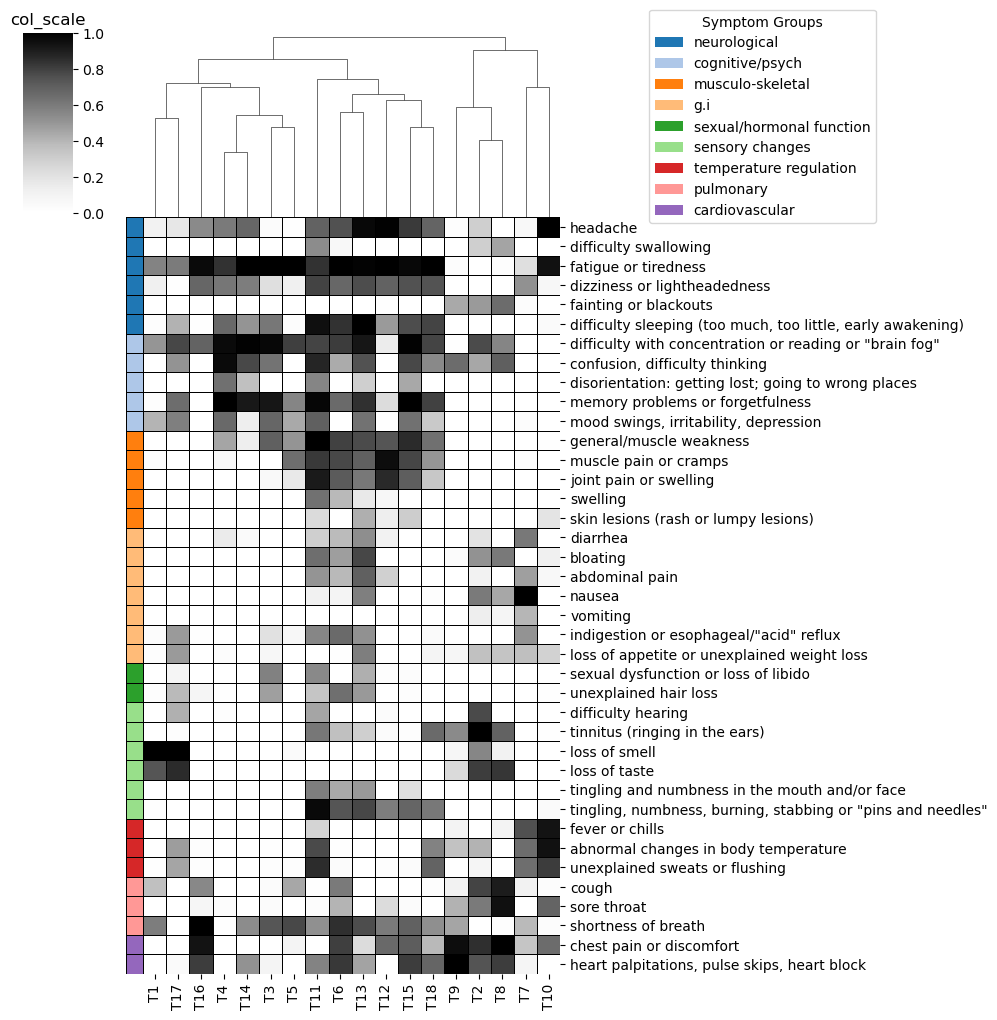

In [4]:
topic_matrix = pd.DataFrame(data['Phi_mean'])
print(topic_matrix.shape[0], "symptoms", topic_matrix.shape[1], "topics")
topic_matrix.columns = ["T" + str(val) for val in range(1, topic_matrix.shape[1] + 1)]
topic_matrix.index = pd.CategoricalIndex(symptoms, categories = symptoms_ordered)
topic_matrix = topic_matrix.sort_index()
# topic_matrix = topic_matrix.div(topic_matrix.sum(axis=1), axis=0) #### row-wise normalizing
print(topic_matrix.sum(0)[:3])
print(topic_matrix.sum(1)[:3])
ax = sns.clustermap(topic_matrix, vmin = 0, col_cluster = True, row_cluster = False, row_colors = symptoms_ordered_colors, 
                    standard_scale = 1, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
handles = [Patch(facecolor=color_mapping[key]) for key in color_mapping.keys()]
plt.legend(handles, color_mapping, title='Symptom Groups',
           bbox_to_anchor=(0.88, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 10)
a = plt.title("col_scale") # 1
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model_emory_sinai_v1/PFA_trained_model_n675_k18.mat


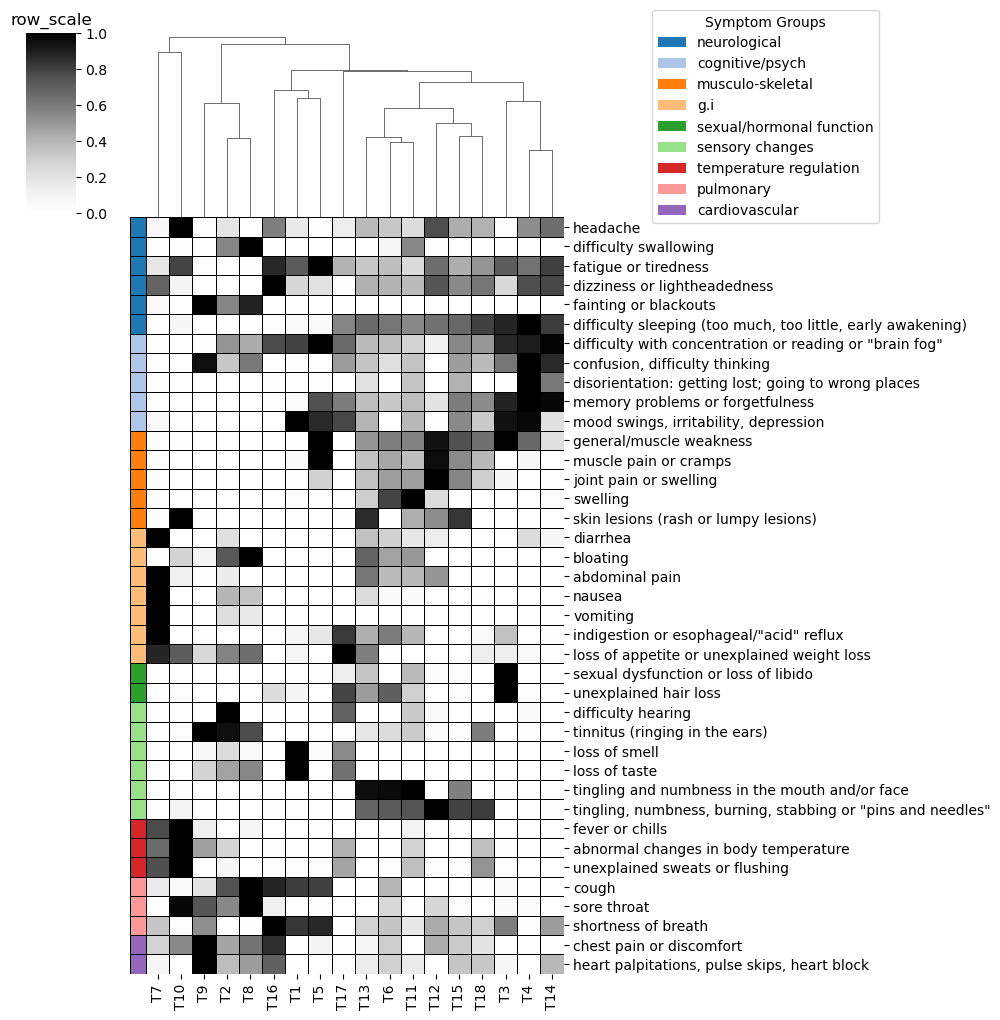

In [5]:
ax = sns.clustermap(topic_matrix, vmin = 0, col_cluster = True, row_cluster = False, row_colors = symptoms_ordered_colors, 
                    standard_scale = 0, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
handles = [Patch(facecolor=color_mapping[key]) for key in color_mapping.keys()]
plt.legend(handles, color_mapping, title='Symptom Groups',
           bbox_to_anchor=(0.88, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 10)
a = plt.title("row_scale") # 0
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model_emory_sinai_v1/PFA_trained_model_n675_k18.mat


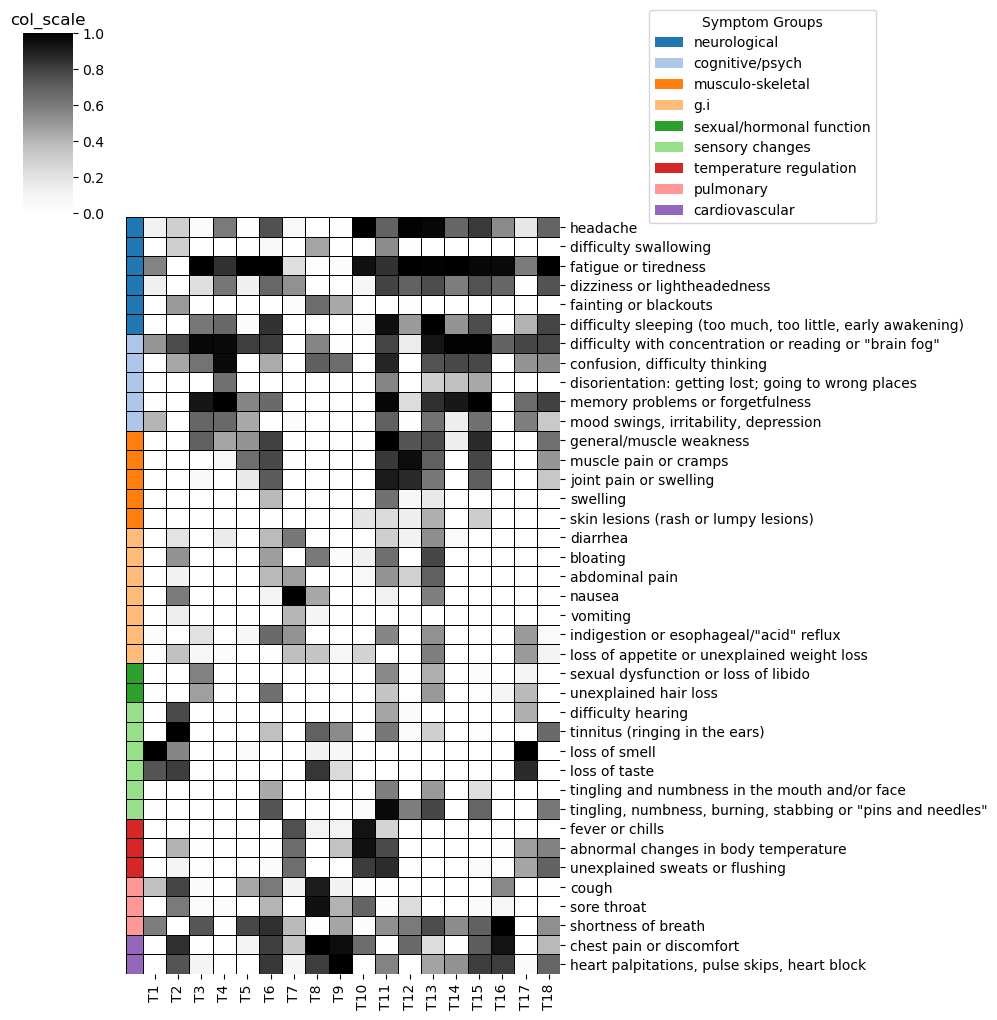

In [6]:
ax = sns.clustermap(topic_matrix, vmin = 0, col_cluster = False, row_cluster = False, row_colors = symptoms_ordered_colors, 
                    standard_scale = 1, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
handles = [Patch(facecolor=color_mapping[key]) for key in color_mapping.keys()]
plt.legend(handles, color_mapping, title='Symptom Groups',
           bbox_to_anchor=(0.88, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 10)
a = plt.title("col_scale") # 0
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model_emory_sinai_v1/PFA_trained_model_n675_k18.mat


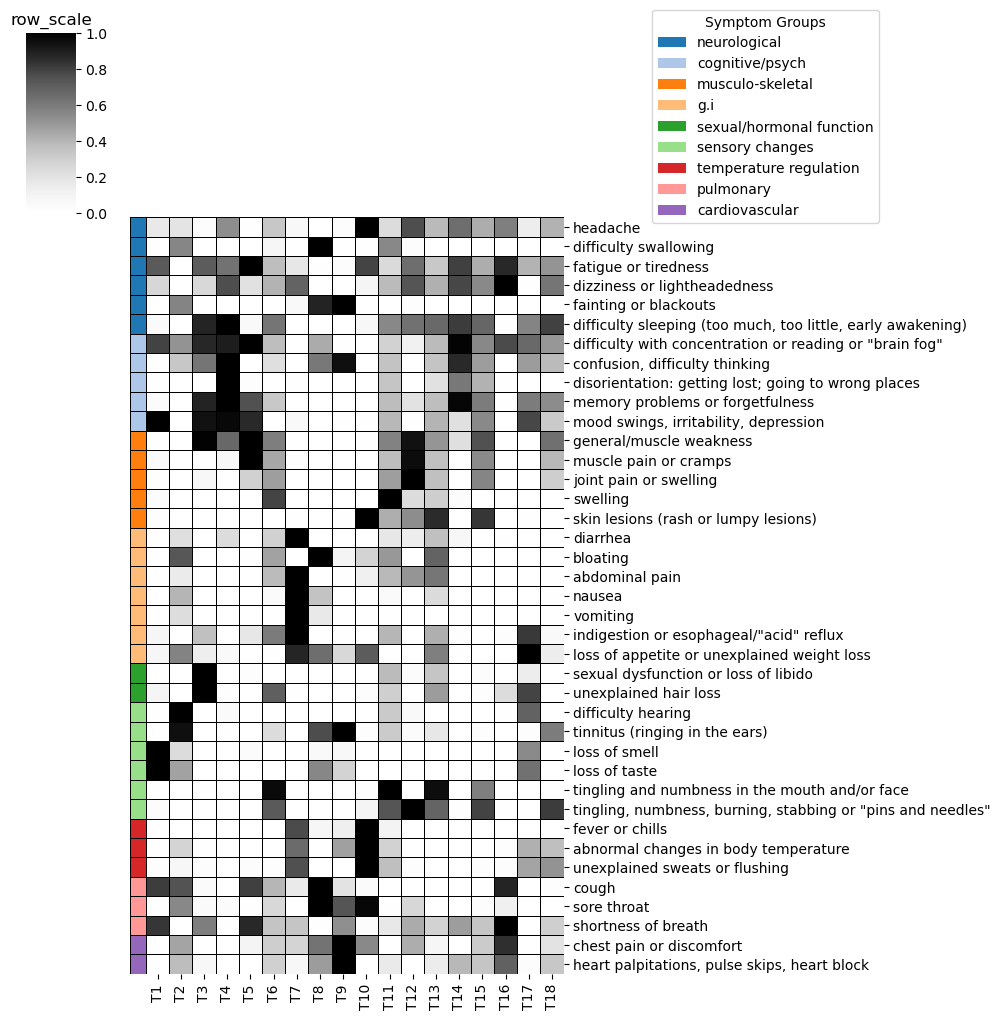

In [7]:
ax = sns.clustermap(topic_matrix, vmin = 0, col_cluster = False, row_cluster = False, row_colors = symptoms_ordered_colors, 
                    standard_scale = 0, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
handles = [Patch(facecolor=color_mapping[key]) for key in color_mapping.keys()]
plt.legend(handles, color_mapping, title='Symptom Groups',
           bbox_to_anchor=(0.88, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 10)
a = plt.title("row_scale") # 0
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model_emory_sinai_v1/PFA_trained_model_n675_k18.mat


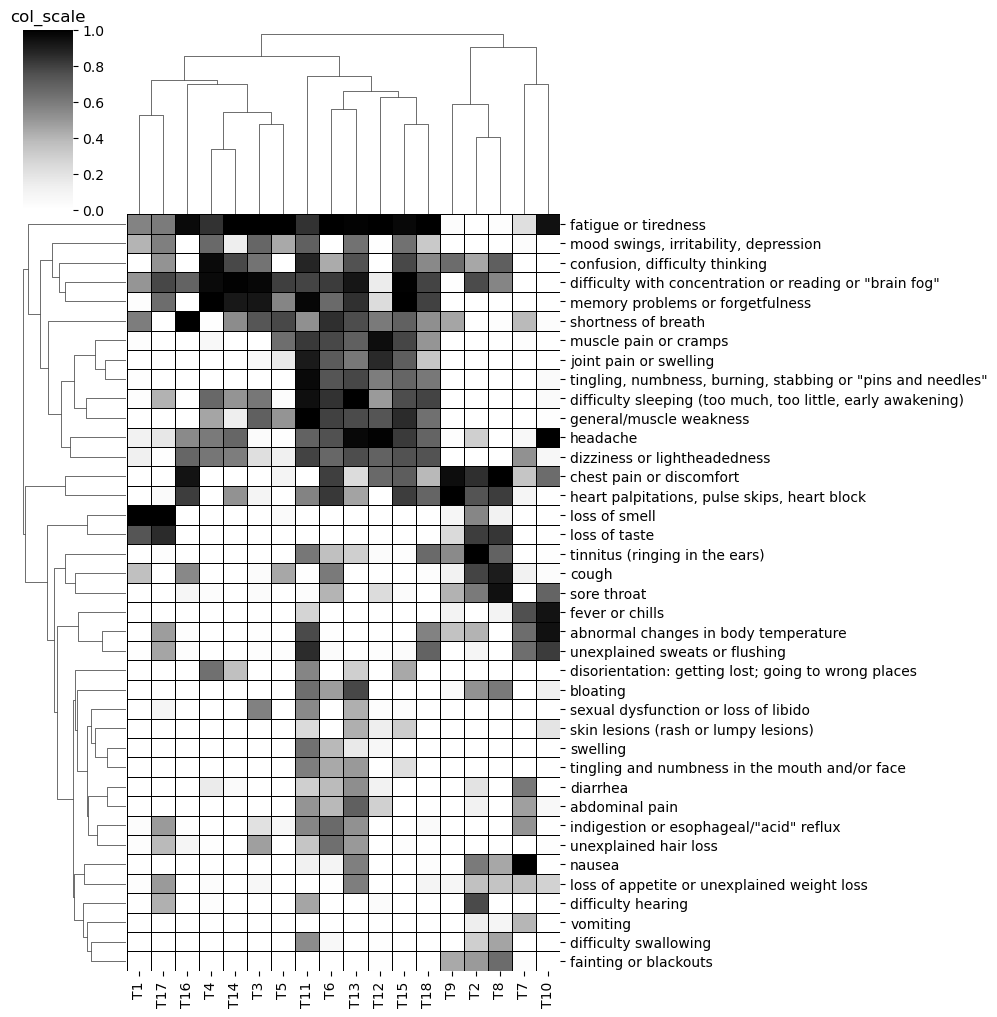

In [8]:
ax = sns.clustermap(topic_matrix, vmin = 0, col_cluster = True, row_cluster = True, #row_colors = symptoms_ordered_colors, 
                    standard_scale = 1, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 10)
a = plt.title("col_scale") # 1
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model_emory_sinai_v1/PFA_trained_model_n675_k18.mat


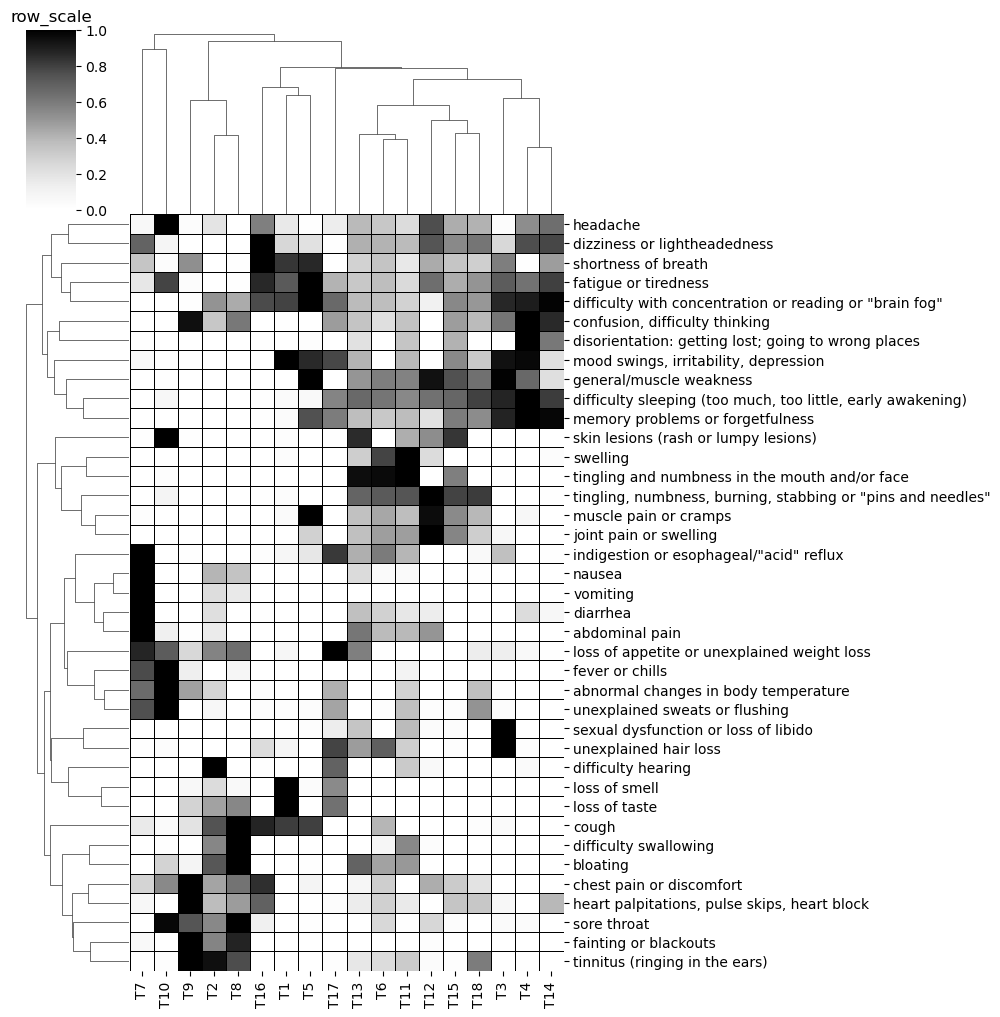

In [9]:
ax = sns.clustermap(topic_matrix, vmin = 0, col_cluster = True, row_cluster = True, #row_colors = symptoms_ordered_colors, 
                    standard_scale = 0, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 10)
a = plt.title("row_scale") # 0
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

# Clustering

Counter({1: 239, 2: 50, 3: 43, 5: 38, 4: 38, 6: 36, 7: 35, 8: 28, 11: 25, 10: 25, 9: 25, 12: 24, 13: 23, 14: 22, 16: 12, 15: 12})
trained_topic_model_emory_sinai_v1/PFA_trained_model_n675_k18.mat


<Figure size 640x480 with 0 Axes>

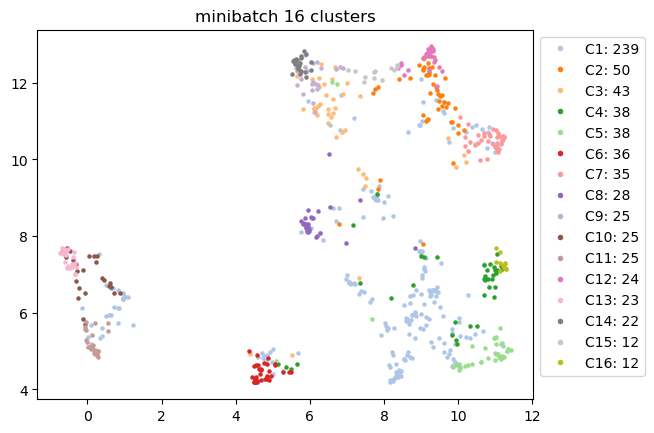

In [10]:
topic_proportions = pd.DataFrame(data['Theta_mean']).T
topic_proportions_norm = topic_proportions/topic_proportions.sum(1)[:,np.newaxis]
topic_proportions_norm = preprocessing.normalize(topic_proportions)
UMAP = umap.UMAP(metric='euclidean', n_neighbors=30, random_state=916)
embedding = UMAP.fit_transform(topic_proportions_norm)
clusters = get_clusters(clustering_method, n_clusters)
topic_proportions_ = pd.DataFrame(topic_proportions).copy()
topic_proportions_["cluster"] = clusters
print(Counter(clusters))
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')
plot_clusters(clusters, embedding, f"{clustering_method} {n_clusters} clusters", colors, None, None)

In [11]:
print(surveys.shape)
len(clusters)
# subset = surveys.iloc[:670,:]
# clust = clusters[:670]
surveys = surveys.replace("3579 3582", 3582)
print(dict(zip(surveys["record_id"].astype(int), clusters)))

(675, 41)
{9: 11, 11: 1, 12: 1, 13: 10, 14: 11, 19: 13, 20: 11, 22: 13, 29: 10, 31: 1, 32: 11, 33: 1, 39: 11, 42: 11, 44: 1, 46: 1, 49: 13, 50: 11, 56: 1, 58: 1, 63: 1, 65: 11, 67: 1, 69: 10, 71: 1, 72: 11, 73: 1, 74: 11, 77: 11, 78: 13, 79: 13, 80: 10, 82: 10, 83: 10, 86: 1, 88: 13, 90: 11, 91: 11, 92: 13, 93: 13, 98: 13, 99: 11, 101: 13, 102: 13, 103: 10, 104: 1, 111: 1, 112: 11, 115: 1, 116: 11, 117: 11, 121: 1, 122: 13, 123: 11, 124: 10, 125: 10, 126: 1, 130: 8, 131: 10, 132: 11, 133: 1, 138: 13, 141: 11, 142: 10, 143: 10, 148: 16, 149: 1, 151: 1, 153: 1, 154: 13, 156: 10, 157: 1, 158: 13, 160: 13, 161: 13, 162: 10, 164: 11, 169: 13, 171: 13, 173: 13, 175: 13, 176: 10, 177: 10, 179: 10, 181: 10, 182: 1, 185: 1, 186: 1, 187: 10, 188: 10, 189: 8, 190: 13, 194: 3, 195: 1, 198: 1, 199: 1, 202: 9, 203: 11, 204: 1, 208: 11, 211: 13, 213: 1, 214: 11, 215: 1, 216: 1, 218: 11, 222: 2, 223: 1, 224: 1, 225: 3, 226: 1, 227: 1, 228: 12, 230: 1, 232: 1, 233: 3, 234: 1, 235: 1, 236: 2, 238: 1, 24

In [12]:
# # Merged endotype clustering
# def plot_clusters(clusters, embedding, title, colors, topic_proportions_, highlights): 
#     plt.figure()
#     fig, ax = plt.subplots()
#     plt.title(title)
#     legend_elements = [] 
#     for i in np.unique(clusters):
#         a = plt.scatter(embedding[clusters==i, 0], embedding[clusters==i, 1], c = colors[i], s = 5)
#         label = f"E{i}: {dict(Counter(clusters))[i]}"
#         legend_elements.append(Line2D([0], [0], label = label, markerfacecolor = colors[i], markersize = 5, marker = 'o', color = 'w'))
#         if highlights: 
#             indeces = topic_proportions_[topic_proportions_["cluster"] == i].index
#             indeces = list(set(indeces) & set(patients))
#             a = plt.scatter(embedding[indeces, 0], embedding[indeces, 1], c = colors[i], s = 100, alpha = 0.5, marker = "^")
#     ax.legend(handles = legend_elements, bbox_to_anchor=(1, 1))
    
# topic_proportions = pd.DataFrame(data['Theta_mean']).T
# topic_proportions_norm = topic_proportions/topic_proportions.sum(1)[:,np.newaxis]
# topic_proportions_norm = preprocessing.normalize(topic_proportions)
# UMAP = umap.UMAP(metric='euclidean', n_neighbors=30, random_state=916)
# embedding = UMAP.fit_transform(topic_proportions_norm)
# clusters = get_clusters(clustering_method, n_clusters)
# topic_proportions_ = pd.DataFrame(topic_proportions).copy()
# topic_proportions_["cluster"] = clusters
# endo_dict = {1:0, 2:1, 3:1, 4:2, 5:3, 6:2, 7:1, 8:4, 9:5, 10:7, 11:7, 12:5, 13:7, 14:5, 15:5, 16:6}
# topic_proportions_["cluster"] = [endo_dict[val] for val in topic_proportions_["cluster"]]
# # topic_proportions_[["cluster", "endotype"]]
# clusters = topic_proportions_["cluster"]
# print(Counter(clusters))
# print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')
# plot_clusters(clusters, embedding, f"{clustering_method} {n_clusters} clusters", colors, None, None)

In [13]:
# print(clusters)

In [14]:
# surveys["cluster"] = clusters
# surveys = surveys[["record_id", "sex", "cluster"]]
# # surveys.to_csv("cluster_assignments_n675_18topics_16clusters_v1.csv", index = False)
# surveys
# for index, row in surveys.iloc[615:,].iterrows(): 
#     print(row["cluster"])

In [15]:
# Emory patients cluster assignment
topic_proportions_["cluster"].iloc[615:].value_counts()

1     35
7      6
3      4
2      4
16     3
4      2
8      2
9      1
6      1
12     1
5      1
Name: cluster, dtype: int64

In [16]:
print(list(topic_proportions_["cluster"].iloc[615:]))

[4, 3, 7, 9, 2, 7, 16, 3, 6, 1, 16, 4, 1, 7, 3, 2, 12, 1, 1, 7, 1, 1, 1, 1, 1, 1, 1, 1, 5, 1, 1, 1, 1, 1, 1, 1, 2, 7, 1, 1, 1, 1, 1, 1, 1, 1, 7, 1, 1, 1, 1, 1, 1, 8, 8, 1, 16, 1, 2, 3]


<Figure size 640x480 with 0 Axes>

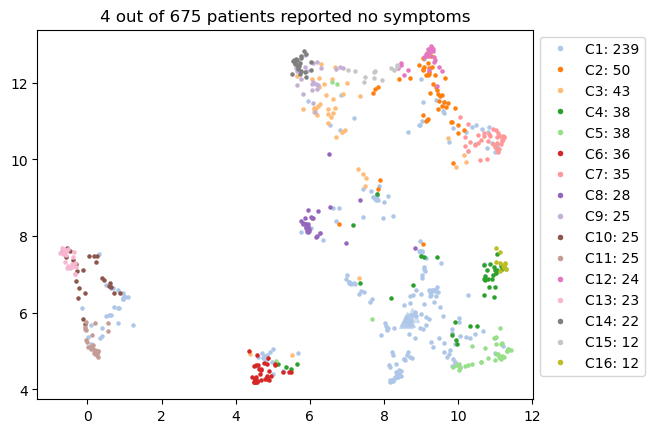

In [17]:
# Highlighting specific patients
title = "reported no symptoms"
patients = surveys[list(filter(re.compile("currentsymptoms_.*").match, surveys.columns))]
patients = list(patients[patients.sum(axis = 1) == 0.0].index)
plot_clusters(clusters, embedding, f"{len(patients)} out of {len(embedding)} patients {title}", colors, topic_proportions_, patients)

In [18]:
# conditions = surveys.copy()
# conditions["cluster"] = ["C" + str(c) for c in clusters]
# dictionary = dict(conditions["cluster"].value_counts())
# df = pd.DataFrame({"cluster": dictionary.keys(), "total": dictionary.values()})
# df = df.sort_values(["total", "cluster"], ascending = [False, True])
# for condition in comorb_dict.keys(): 
#     patients = list(conditions[conditions[condition] == 1.0].index)
#     dictionary = dict(conditions.iloc[patients, :]["cluster"].value_counts())
#     df2 = pd.DataFrame({"cluster": list(dictionary.keys()), comorb_dict[condition]: list(dictionary.values())})
#     df = df.merge(df2, on = "cluster", how = "outer")
#     df["proportion_" + comorb_dict[condition]] = df[comorb_dict[condition]] / df["total"]
# # df.to_csv("comorb_proportions_sinai.csv", index = False)
# df

In [19]:
# # Highlighting specific conditions
# condition = "comorb_selfreport_1"
# if "comorb_" in condition: title = comorb_dict[condition]
# else: title = condition
# patients = list(surveys[surveys[condition] == 1.0].index)
# print(surveys[condition].value_counts())
# plot_clusters(clusters, embedding, f"{len(patients)} out of {len(embedding)} patients with {title}", colors, topic_proportions_, patients)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


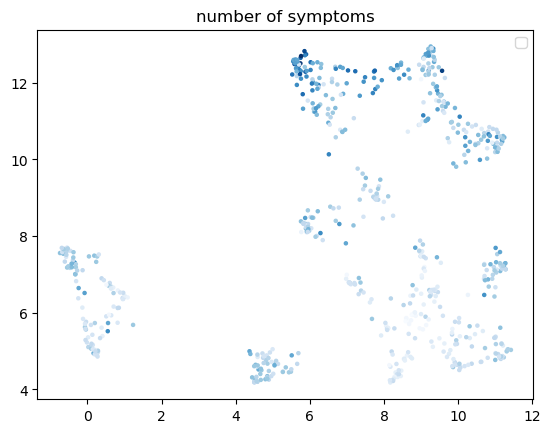

In [20]:
# Colored based on number of symptoms
plt.figure()
conditions = surveys[list(filter(re.compile("currentsymptoms_.*").match, surveys.columns))]
conditions["all"] = conditions.sum(axis = 1)
a = plt.scatter(embedding[:, 0], embedding[:, 1], c = conditions["all"], cmap = "Blues", s = 5)
a = plt.title("number of symptoms")
a = plt.legend()

# Topic Proportions by Cluster

In [21]:
topic_proportions = pd.DataFrame(data['Theta_mean'].T)
topic_proportions.columns = ["T" + str(val) for val in range(1, topic_proportions.shape[1] + 1)]
topic_proportions_ = topic_proportions.copy()
topic_proportions_["cluster"] = clusters
topic_proportions_bycluster = topic_proportions_.groupby("cluster").mean()
topic_proportions_bycluster.index = ["C" + str(val) for val in topic_proportions_bycluster.index]
topic_proportions_bycluster = topic_proportions_bycluster.T
print(topic_proportions_bycluster.shape[0], "topics",  topic_proportions_bycluster.shape[1], "clusters", topic_proportions.shape[0], "patients")
# topic_proportions_bycluster = topic_proportions_bycluster.div(topic_proportions_bycluster.sum(axis=1), axis=0) #### row-wise normalizing
# topic_proportions_bycluster = topic_proportions_bycluster.div(topic_proportions_bycluster.sum(axis=0), axis=1) #### column-wise normalizing
print(topic_proportions_bycluster.sum(0)[:3])
print(topic_proportions_bycluster.sum(1)[:3])

18 topics 16 clusters 675 patients
C1     6.323171
C2    14.865953
C3    14.180193
dtype: float64
T1     6.089085
T2    19.627628
T3     6.773043
dtype: float64


trained_topic_model_emory_sinai_v1/PFA_trained_model_n675_k18.mat


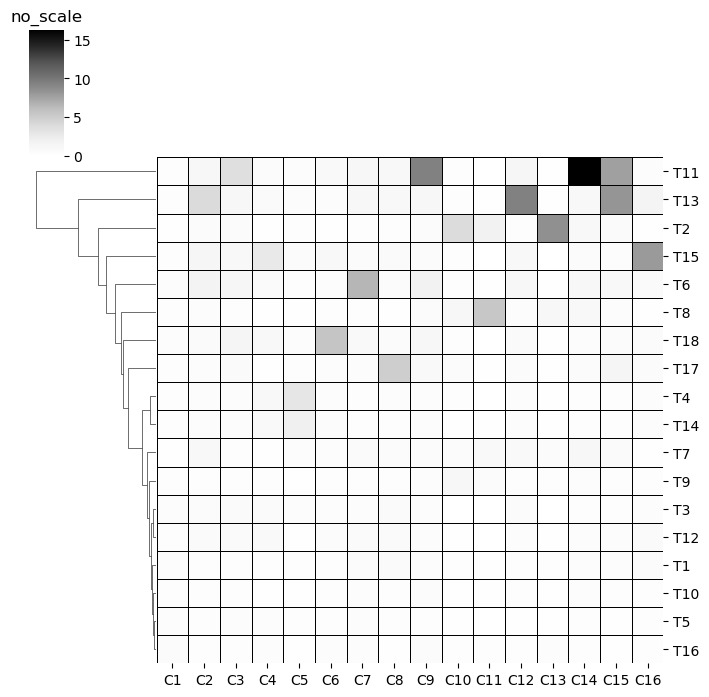

In [22]:
ax = sns.clustermap(topic_proportions_bycluster, vmin = 0, col_cluster = False, row_cluster = True, figsize = (7, 7), 
#                     standard_scale = 1, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
a = plt.title("no_scale") # None
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=0, size = 10)
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model_emory_sinai_v1/PFA_trained_model_n675_k18.mat


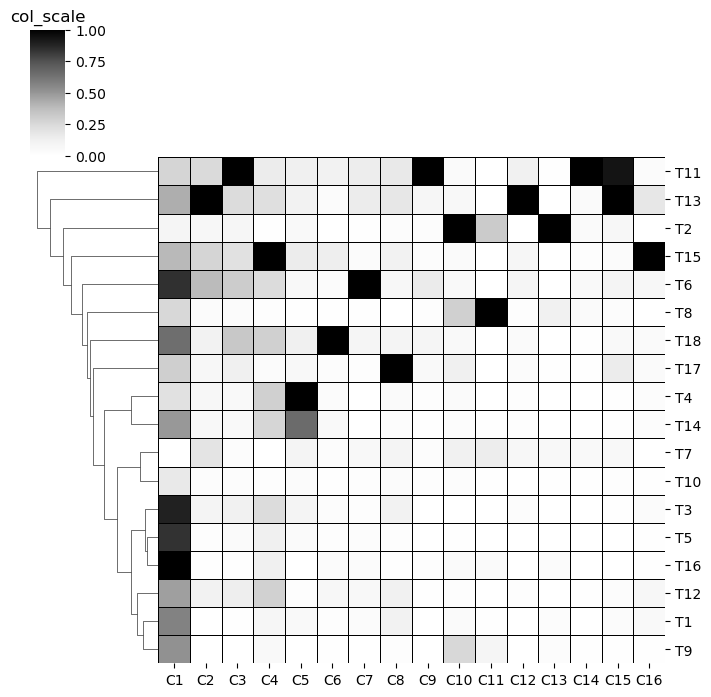

In [23]:
ax = sns.clustermap(topic_proportions_bycluster, vmin = 0, col_cluster = False, row_cluster = True, figsize = (7, 7), 
                    standard_scale = 1, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
a = plt.title("col_scale") # 1
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=0, size = 10)
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model_emory_sinai_v1/PFA_trained_model_n675_k18.mat


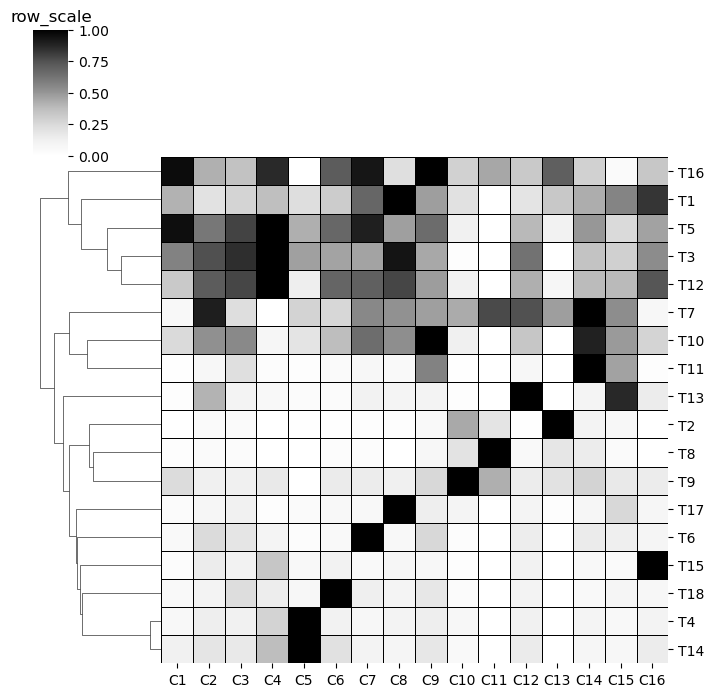

In [24]:
ax = sns.clustermap(topic_proportions_bycluster, vmin = 0, col_cluster = False, row_cluster = True, figsize = (7, 7), 
                    standard_scale = 0, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
a = plt.title("row_scale") # 0
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=0, size = 10)
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

# Cluster by Symptom Heatmap

In [25]:
cluster_by_symptom = pd.DataFrame(np.dot(topic_matrix, topic_proportions_bycluster))
print(cluster_by_symptom.shape, "=", topic_matrix.shape, "x", topic_proportions_bycluster.shape)
cluster_by_symptom.index = topic_matrix.index
cluster_by_symptom.columns = ["C" + str(val) for val in range(1, cluster_by_symptom.shape[1] + 1)]
# cluster_by_symptom = cluster_by_symptom.div(cluster_by_symptom.sum(axis=1), axis=0) #### row-wise normalizing
# cluster_by_symptom = cluster_by_symptom.div(cluster_by_symptom.sum(axis=0), axis=1) #### column-wise normalizing
print(cluster_by_symptom.sum(0)[:3])
print(cluster_by_symptom.sum(1)[:3])

(39, 16) = (39, 18) x (18, 16)
C1     6.323171
C2    14.865953
C3    14.180193
dtype: float64
headache                 10.708818
difficulty swallowing     2.453255
fatigue or tiredness     15.512283
dtype: float64


trained_topic_model_emory_sinai_v1/PFA_trained_model_n675_k18.mat


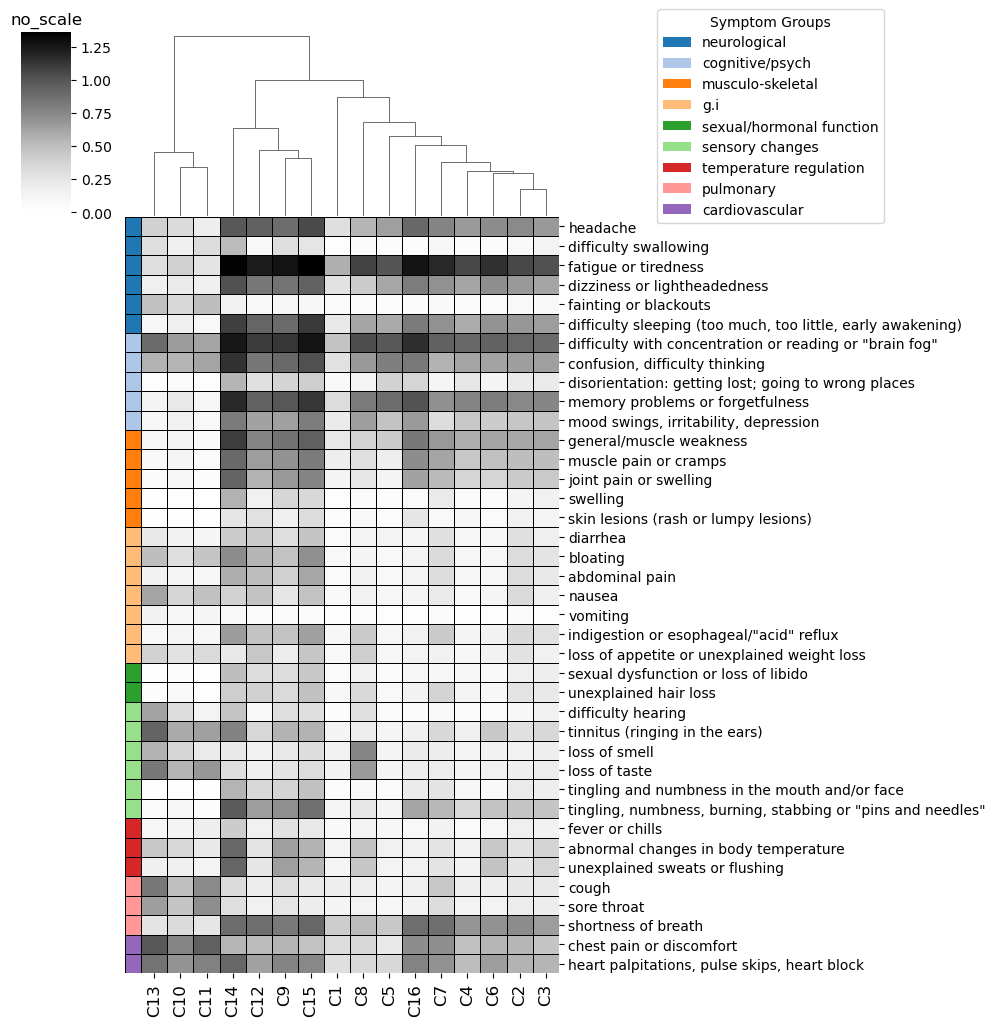

In [26]:
ax = sns.clustermap(cluster_by_symptom, vmin = 0, col_cluster = True, row_cluster = False, row_colors = symptoms_ordered_colors, 
#                     standard_scale = 1, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, 
                    cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
plt.legend(handles, color_mapping, title='Symptom Groups', facecolor = "white", 
           bbox_to_anchor=(0.89, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 12)
a = plt.title("no_scale") # 1
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model_emory_sinai_v1/PFA_trained_model_n675_k18.mat


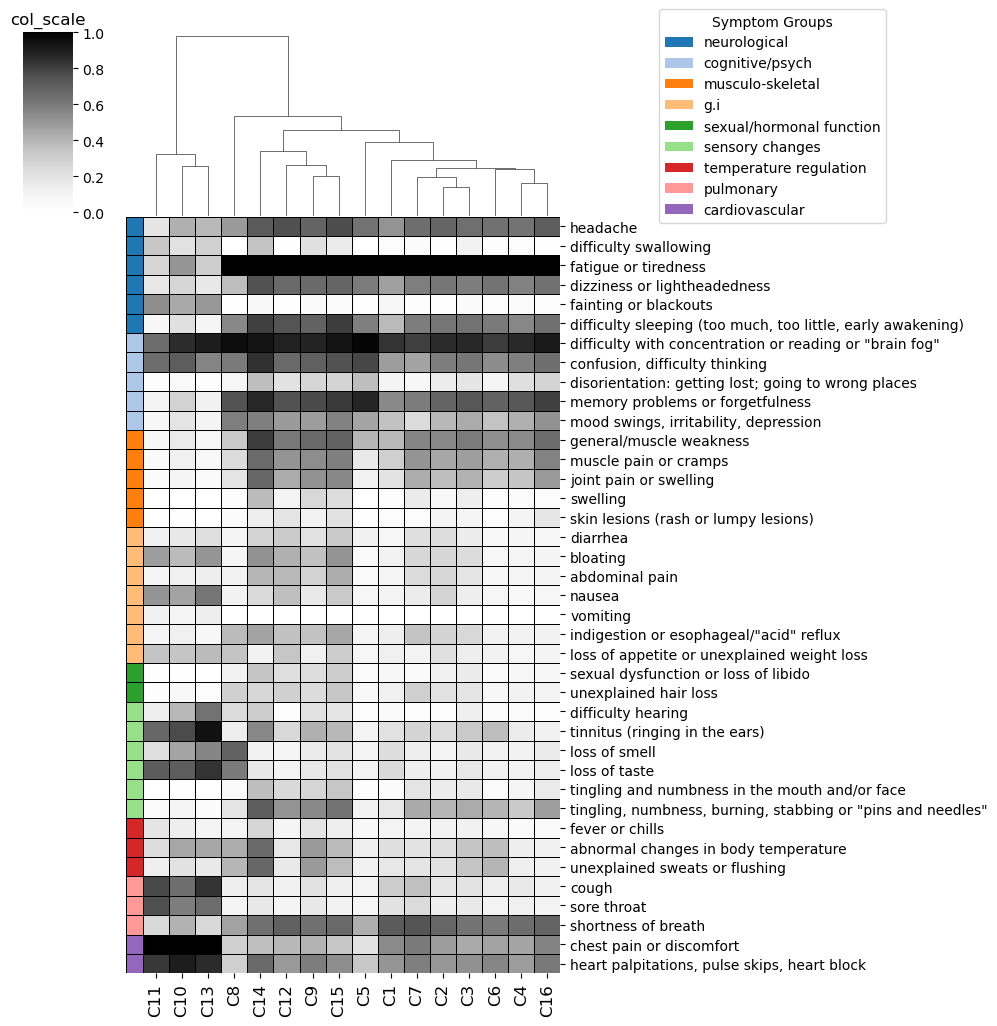

In [27]:
ax = sns.clustermap(cluster_by_symptom, vmin = 0, col_cluster = True, row_cluster = False, row_colors = symptoms_ordered_colors, 
                    standard_scale = 1, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, 
                    cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
plt.legend(handles, color_mapping, title='Symptom Groups', facecolor = "white", 
           bbox_to_anchor=(0.89, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 12)
a = plt.title("col_scale") # 1
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model_emory_sinai_v1/PFA_trained_model_n675_k18.mat


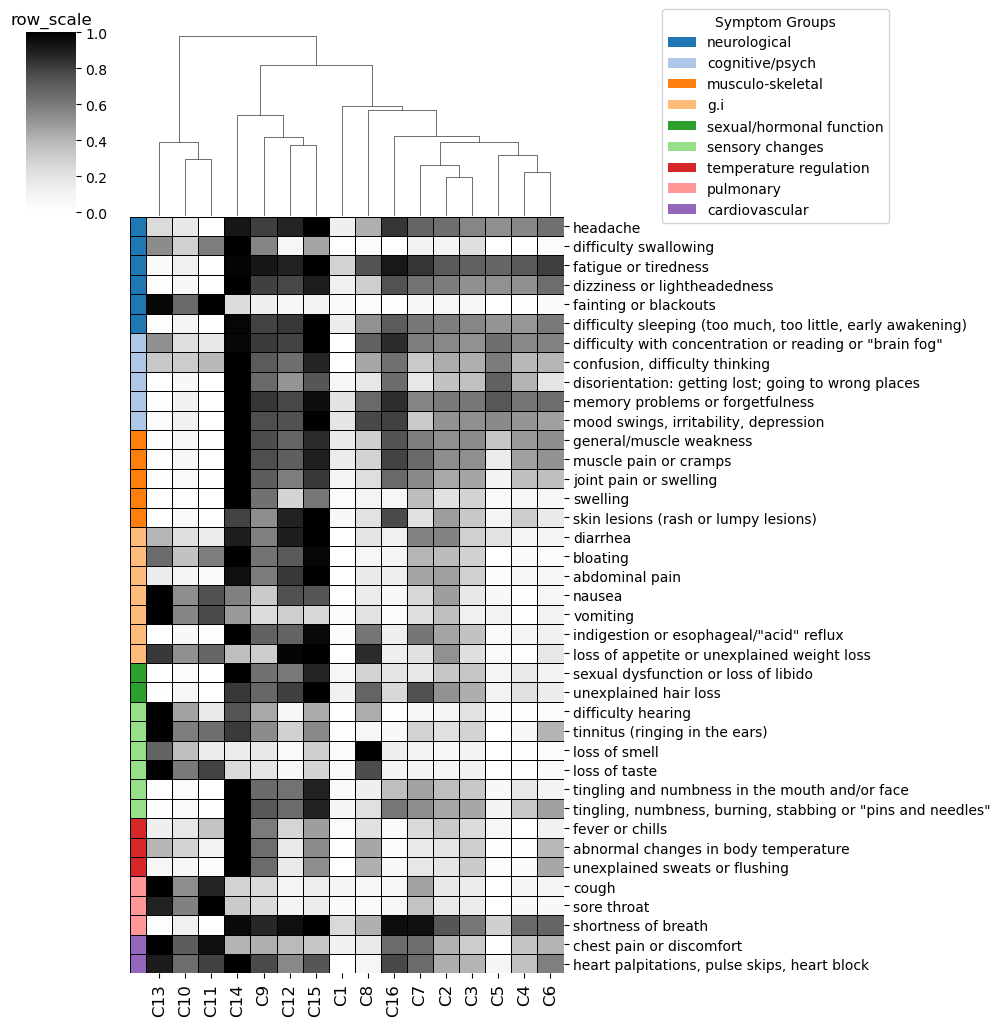

In [28]:
ax = sns.clustermap(cluster_by_symptom, vmin = 0, col_cluster = True, row_cluster = False, row_colors = symptoms_ordered_colors, 
                    standard_scale = 0, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, 
                    cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
plt.legend(handles, color_mapping, title='Symptom Groups', facecolor = "white", 
           bbox_to_anchor=(0.89, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 12)
a = plt.title("row_scale") # 0
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model_emory_sinai_v1/PFA_trained_model_n675_k18.mat


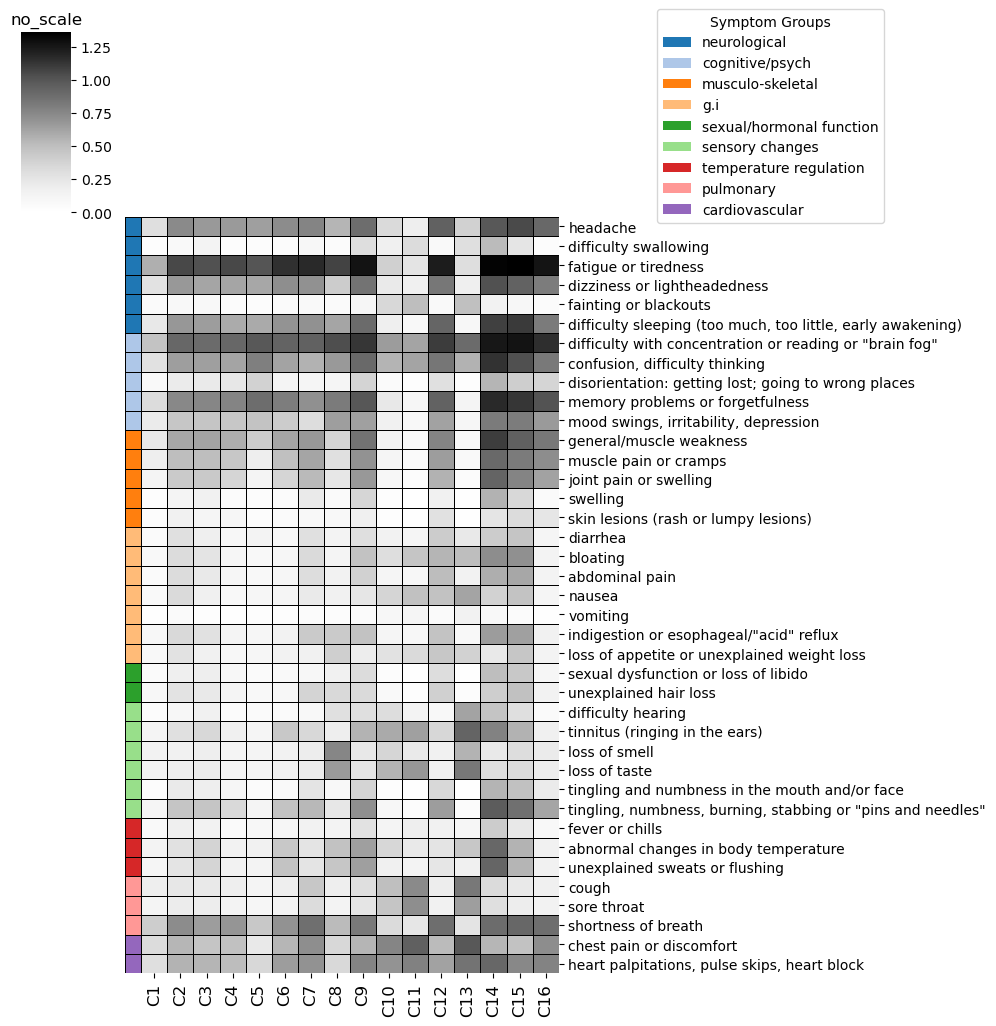

In [29]:
ax = sns.clustermap(cluster_by_symptom, vmin = 0, col_cluster = False, row_cluster = False, row_colors = symptoms_ordered_colors, 
#                     standard_scale = 1, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, 
                    cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
plt.legend(handles, color_mapping, title='Symptom Groups', facecolor = "white", 
           bbox_to_anchor=(0.89, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 12)
a = plt.title("no_scale") # 1
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model_emory_sinai_v1/PFA_trained_model_n675_k18.mat


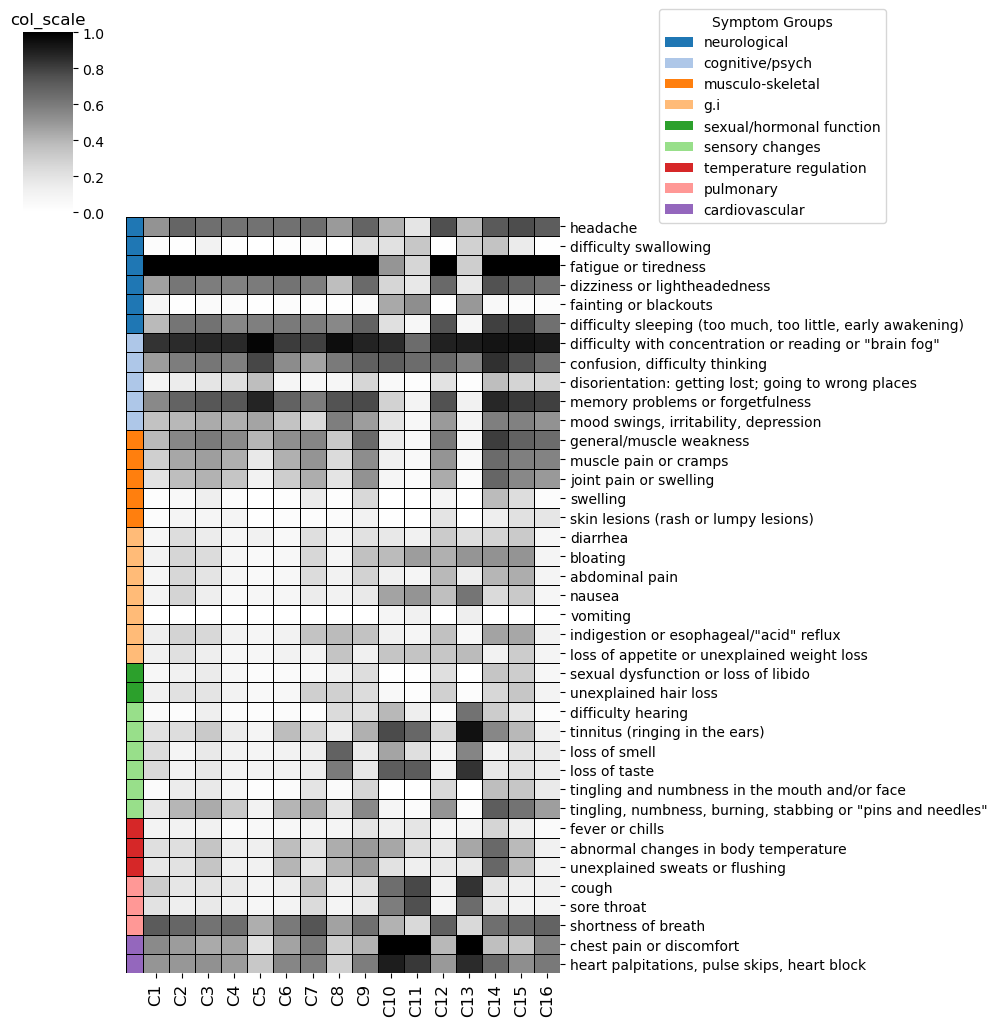

In [30]:
ax = sns.clustermap(cluster_by_symptom, vmin = 0, col_cluster = False, row_cluster = False, row_colors = symptoms_ordered_colors, 
                    standard_scale = 1, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, 
                    cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
plt.legend(handles, color_mapping, title='Symptom Groups', facecolor = "white", 
           bbox_to_anchor=(0.89, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 12)
a = plt.title("col_scale") # 1
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

trained_topic_model_emory_sinai_v1/PFA_trained_model_n675_k18.mat


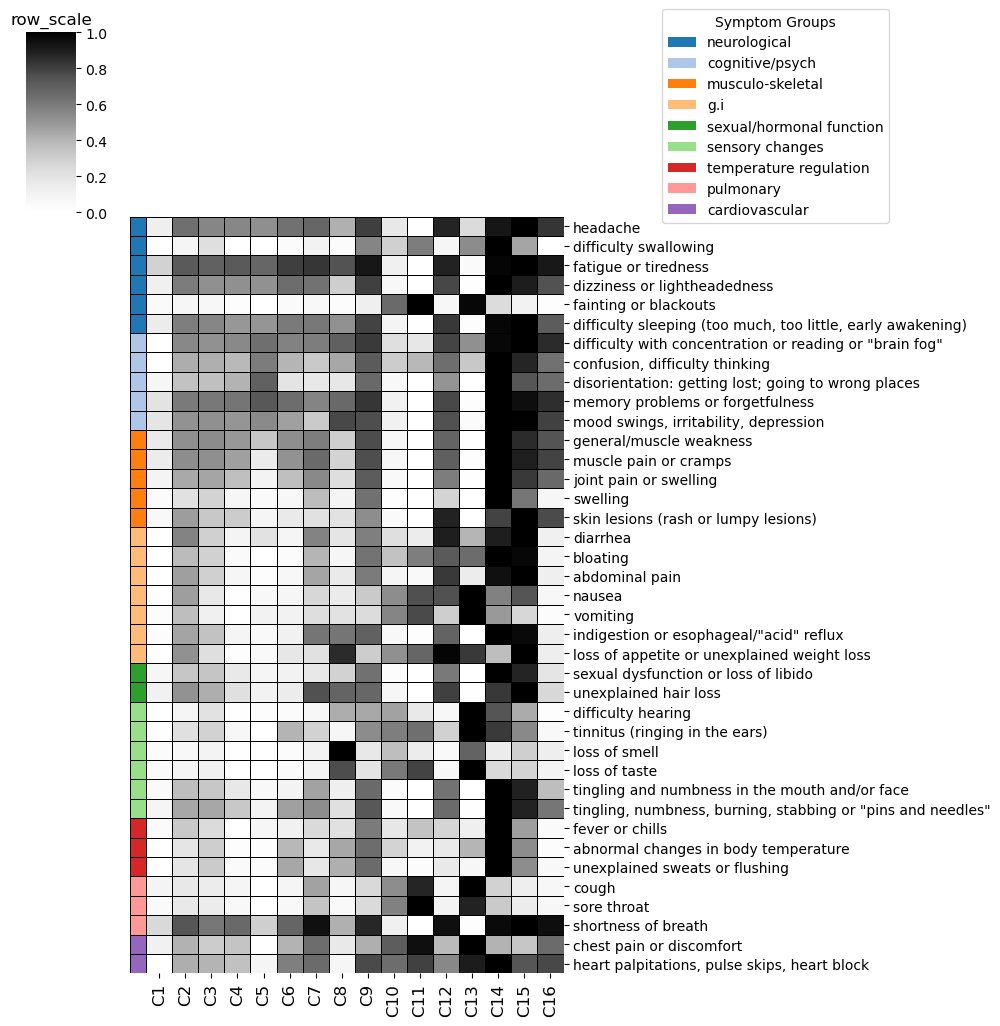

In [31]:
ax = sns.clustermap(cluster_by_symptom, vmin = 0, col_cluster = False, row_cluster = False, row_colors = symptoms_ordered_colors, 
                    standard_scale = 0, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, 
                    cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
plt.legend(handles, color_mapping, title='Symptom Groups', facecolor = "white", 
           bbox_to_anchor=(0.89, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 12)
a = plt.title("row_scale") # 0
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

# Defining symptom severity groups

In [32]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# https://github.com/mwaskom/seaborn/blob/86b5481ca47cb46d3b3e079a5ed9b9fb46e315ef/seaborn/matrix.py#L892

# Standardize the data
standardized = cluster_by_symptom.copy().T
subtract = standardized.min()
standardized = (standardized - subtract) / (standardized.max() - standardized.min())
standardized = standardized.T

# # Plotting to check same as sns.clustermap standard_scaling
# ax = sns.clustermap(standardized, vmin = 0, col_cluster = True, row_cluster = False, row_colors = symptoms_ordered_colors, 
# #                     standard_scale = 0, 
#                     xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, 
#                     cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)

standardized

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,C15,C16
headache,0.132479,0.637766,0.555669,0.551218,0.526541,0.632526,0.674413,0.415740,0.802341,0.169779,0.000000,0.878357,0.241328,0.925448,1.000000,0.831549
difficulty swallowing,0.000000,0.086806,0.217461,0.007655,0.003010,0.034150,0.110466,0.032897,0.561032,0.291407,0.587694,0.078353,0.538136,1.000000,0.449608,0.004634
fatigue or tiredness,0.283374,0.722627,0.693971,0.721529,0.675549,0.802243,0.826705,0.744156,0.918716,0.122923,0.000000,0.883075,0.042762,0.980723,1.000000,0.915752
dizziness or lightheadedness,0.125191,0.592362,0.522362,0.522783,0.515991,0.648317,0.625319,0.297548,0.799674,0.055721,0.000000,0.777667,0.010276,1.000000,0.900619,0.747174
fainting or blackouts,0.045329,0.080940,0.072897,0.019194,0.000000,0.039836,0.056287,0.027201,0.130477,0.657662,1.000000,0.063806,0.972695,0.235331,0.105575,0.018626
"difficulty sleeping (too much, too little, early awakening)",0.147321,0.582541,0.556917,0.496554,0.501550,0.600316,0.607669,0.517993,0.789893,0.096980,0.000000,0.822380,0.015813,0.979527,1.000000,0.713964
"difficulty with concentration or reading or ""brain fog""",0.000000,0.548991,0.518376,0.544068,0.638869,0.570548,0.588832,0.698114,0.816398,0.222646,0.177454,0.787481,0.521430,0.976277,1.000000,0.855756
"confusion, difficulty thinking",0.000000,0.426161,0.418285,0.389535,0.590232,0.400993,0.321674,0.445887,0.718500,0.309494,0.392749,0.644522,0.326833,1.000000,0.873266,0.629580
disorientation: getting lost; going to wrong places,0.076656,0.352264,0.360167,0.406297,0.694083,0.192894,0.170755,0.174675,0.662321,0.061541,0.000000,0.504554,0.006829,1.000000,0.732027,0.648640
memory problems or forgetfulness,0.199056,0.597686,0.607635,0.617694,0.726487,0.647447,0.565875,0.661447,0.826376,0.116545,0.000000,0.776690,0.018704,1.000000,0.952486,0.850775


In [33]:
severity = pd.DataFrame(standardized.sum()).rename(columns = {0: "sum"})
severity

,sum
C1,2.693430
C2,15.267783
C3,13.622445
C4,9.349821
C5,7.531502
C6,11.455695
C7,16.085832
C8,13.575812
C9,23.020574
C10,10.143111


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
[2.693430126565952, 15.267783388134077, 13.622444758818038, 9.349821437001479, 7.531502417733883, 11.455694586117241, 16.085832351121763, 13.575811994776776, 23.02057402795433, 10.143111441440476, 11.0002448479398, 21.085280348374372, 14.941260304234193, 31.910781562092247, 28.21574051988618, 15.158387731989784]


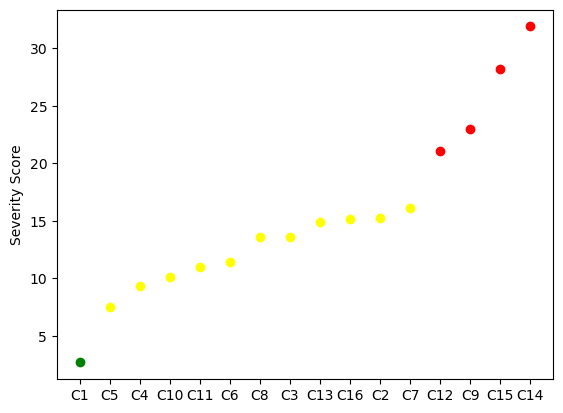

In [34]:
severity = pd.DataFrame(standardized.sum()).rename(columns = {0: "sum"}).reset_index()
severity["cluster"] = [int(val.replace("C", "")) for val in severity["index"]]
print(list(severity.index))
print(list(severity["sum"]))
severity = severity.sort_values("sum").reset_index()
colors = ["green"]
colors.extend(["yellow"]*11)
colors.extend(["red"]*4)
severity["color"] = colors
for index, row in severity.iterrows(): 
    a = plt.scatter([index], row["sum"], c = row["color"])
# a = plt.scatter(range(1, 17), severity["sum"])
a = plt.ylabel("Severity Score")
a = plt.xticks(range(0, severity.shape[0]), severity["index"])

# Star Charts per Cluster

In [35]:
patient_by_symptom = pd.DataFrame(np.dot(topic_matrix, topic_proportions.T))
print(patient_by_symptom.shape,  "=", topic_matrix.shape, "+", topic_proportions.T.shape)
patient_by_symptom.index = topic_matrix.index
patient_by_symptom = patient_by_symptom.T
# patient_by_symptom = patient_by_symptom.div(patient_by_symptom.sum(axis=1), axis=0) #### row-wise normalizing
# patient_by_symptom = patient_by_symptom.div(patient_by_symptom.sum(axis=0), axis=1) #### column-wise normalizing
print(patient_by_symptom.sum(0)[:3])
print(patient_by_symptom.sum(1)[:3])
patient_by_symptom["cluster"] = clusters

#### Adding endotype
patient_by_symptom["cluster"]

patient_by_symptom
df = pd.DataFrame()
cluster_by_symptom_norm = cluster_by_symptom.div(cluster_by_symptom.sum(axis=1), axis=0) #### row-wise normalizing
for col in cluster_by_symptom_norm.columns: 
    subset = cluster_by_symptom_norm[col].sort_values(ascending = False)
    df[col + "_sym"] = subset.index
    df[col + "_pro"] = [round(val, 3) for val in list(subset)]
columns = list(filter(re.compile(".*sym").match, df.columns))
cluster_topsymptoms = df[columns].copy()
cluster_topsymptoms.columns = [col.split("_")[0] for col in cluster_topsymptoms.columns]
cluster_topsymptoms.head(6)

(39, 675) = (39, 18) + (18, 675)
headache                 366.124231
difficulty swallowing     68.769497
fatigue or tiredness     568.835270
dtype: float64
0     6.993641
1     4.900334
2    13.750408
dtype: float64


,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,C15,C16
0,shortness of breath,diarrhea,swelling,fatigue or tiredness,disorientation: getting lost; going to wrong p...,unexplained sweats or flushing,unexplained hair loss,loss of smell,swelling,fainting or blackouts,fainting or blackouts,skin lesions (rash or lumpy lesions),fainting or blackouts,swelling,sexual dysfunction or loss of libido,skin lesions (rash or lumpy lesions)
1,cough,abdominal pain,unexplained sweats or flushing,shortness of breath,memory problems or forgetfulness,abnormal changes in body temperature,swelling,loss of taste,difficulty swallowing,sore throat,sore throat,abdominal pain,difficulty hearing,difficulty swallowing,tingling and numbness in the mouth and/or face,disorientation: getting lost; going to wrong p...
2,fatigue or tiredness,skin lesions (rash or lumpy lesions),general/muscle weakness,memory problems or forgetfulness,"confusion, difficulty thinking",dizziness or lightheadedness,"indigestion or esophageal/""acid"" reflux",loss of appetite or unexplained weight loss,unexplained sweats or flushing,loss of taste,cough,diarrhea,vomiting,sexual dysfunction or loss of libido,skin lesions (rash or lumpy lesions),muscle pain or cramps
3,loss of smell,unexplained hair loss,joint pain or swelling,disorientation: getting lost; going to wrong p...,"difficulty with concentration or reading or ""b...",fatigue or tiredness,cough,unexplained hair loss,sexual dysfunction or loss of libido,vomiting,vomiting,sexual dysfunction or loss of libido,cough,tingling and numbness in the mouth and/or face,abdominal pain,joint pain or swelling
4,chest pain or discomfort,nausea,muscle pain or cramps,general/muscle weakness,"mood swings, irritability, depression","tingling, numbness, burning, stabbing or ""pins...",tingling and numbness in the mouth and/or face,difficulty hearing,tingling and numbness in the mouth and/or face,difficulty hearing,loss of taste,loss of appetite or unexplained weight loss,loss of taste,unexplained sweats or flushing,swelling,general/muscle weakness
5,"difficulty with concentration or reading or ""b...",vomiting,sexual dysfunction or loss of libido,dizziness or lightheadedness,fatigue or tiredness,"difficulty sleeping (too much, too little, ear...",shortness of breath,"indigestion or esophageal/""acid"" reflux",fever or chills,cough,difficulty swallowing,tingling and numbness in the mouth and/or face,sore throat,fever or chills,unexplained hair loss,"tingling, numbness, burning, stabbing or ""pins..."


In [36]:
dictionary = {}
for index, row in patient_by_symptom.iterrows(): 
    cluster = "C" + str(int(row["cluster"]))
    symptoms_subset = list(cluster_topsymptoms[cluster])[:6]
    symptoms_subset.append(symptoms_subset[0])
    values = [row[s] for s in symptoms_subset]
    values.append(values[0])
    dictionary[index] = dict(r = values, theta = symptoms_subset)
print(len(dictionary))
# dictionary

675


In [37]:
# Adding sexes if provided
print(dict(surveys["sex"].value_counts()))
# count_sex = {"rgba(0,255,0,0.25)": 0, "rgba(0,0,255,0.25)": 0, "rgba(50,50,50,0.25)": 0}
# count_sex = {"rgb(0,255,0)": 0, "rgb(0,0,255)": 0, "rgb(50,50,50)": 0}
count_sex = {"rgb(0,0,255)": 0, "rgb(255,0,0)": 0, "rgb(50,50,50)": 0}
values = []
for val in surveys["sex"]: 
#     print(val)
    if str(val) == "1.0" or str(val) == "M": # M
        values.append(list(count_sex.keys())[0])
    elif str(val) == "2.0" or str(val) == "F": # F
        values.append(list(count_sex.keys())[1])
    else: # else
        values.append(list(count_sex.keys())[2])
sexes = values[:]
print(len(sexes), Counter(sexes))

{'F': 480, 'M': 180}
675 Counter({'rgb(255,0,0)': 480, 'rgb(0,0,255)': 180, 'rgb(50,50,50)': 15})


In [38]:
def star_chart_per_patient(cluster): 
    scatterpolars = []
#     count_sex = {"rgba(0,255,0,0.75)": 0, "rgba(0,0,255,0.75)": 0, "rgba(50,50,50,0.25)": 0}
#     count_sex = {"rgb(0,255,0)": 0, "rgb(0,0,255)": 0, "rgb(50,50,50)": 0}
    count_sex = {"rgb(0,0,255)": 0, "rgb(255,0,0)": 0, "rgb(50,50,50)": 0}
    for i in list(patient_by_symptom[patient_by_symptom["cluster"] == cluster].index)[:]: 
        scatterpolars.append(go.Scatterpolar(dictionary[i], # fill = "toself", fillcolor = sexes[i], 
                                             mode = "lines",            
                                             name = "Patient" + str(i+1), 
                                             line_color = sexes[i], 
#                                              line = {"opacity": 0.25}, 
#                                              line_color = "rgba(100,25,25,0.25)", 
                                            ))
        count_sex[sexes[i]] += 1
    fig = go.Figure(data = scatterpolars)
    fig.update_traces(opacity = 0.25)
    # fig.update_polars(radialaxis=dict(range=[0, 1]))
    count_sex_str = str(count_sex).replace(list(count_sex.keys())[0], "M (blue)").replace(list(count_sex.keys())[1], "F (red)").replace(list(count_sex.keys())[2], "nan (gray)")
#     count_sex_str = ""
    fig.update_layout(title = ".\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\tCluster" + str(cluster) + ": " + str(len(scatterpolars)) + " patients " + count_sex_str)
    return fig

star_chart_per_patient(1)

In [39]:
star_chart_per_patient(2)

In [40]:
star_chart_per_patient(3)

In [41]:
star_chart_per_patient(4)

In [42]:
star_chart_per_patient(5)

In [43]:
star_chart_per_patient(6)

In [44]:
star_chart_per_patient(7)

In [45]:
star_chart_per_patient(8)

In [46]:
star_chart_per_patient(9)

In [47]:
star_chart_per_patient(10)

In [48]:
star_chart_per_patient(11)

In [49]:
star_chart_per_patient(12)

In [50]:
star_chart_per_patient(13)

In [51]:
star_chart_per_patient(14)

In [52]:
star_chart_per_patient(15)

In [53]:
star_chart_per_patient(16)

# Star Charts Median

In [54]:
def star_chart_median(cluster): 
    dictionary = {}
    symptoms_subset = list(cluster_topsymptoms["C" + str(cluster)])[:6]
    cluster_subset = patient_by_symptom[patient_by_symptom["cluster"] == cluster]
    cluster_subset["sex"] = surveys["sex"]
    for sex in ["F", "M"]: 
        cluster_sex_subset = cluster_subset[cluster_subset["sex"] == sex]
        cluster_sex_subset = cluster_sex_subset.median()[symptoms_subset]
        cluster_sex_subset = dict(cluster_sex_subset)
        key = f"{sex} (in cluster)"
        dictionary[key] = dict(r = list(cluster_sex_subset.values()), theta = list(cluster_sex_subset.keys()))
        dictionary[key]["r"].append(dictionary[key]["r"][0])
        dictionary[key]["theta"].append(dictionary[key]["theta"][0])
    cluster_subset = patient_by_symptom[patient_by_symptom["cluster"] != cluster]
    cluster_subset["sex"] = surveys["sex"]
    for sex in ["F", "M"]: 
        cluster_sex_subset = cluster_subset[cluster_subset["sex"] == sex]
        cluster_sex_subset = cluster_sex_subset.median()[symptoms_subset]
        cluster_sex_subset = dict(cluster_sex_subset)
        key = f"{sex} (global)"
        dictionary[key] = dict(r = list(cluster_sex_subset.values()), theta = list(cluster_sex_subset.keys()))
        dictionary[key]["r"].append(dictionary[key]["r"][0])
        dictionary[key]["theta"].append(dictionary[key]["theta"][0])

    scatterpolars = []
    scatterpolars.append(go.Scatterpolar(dictionary["F (in cluster)"], mode = "lines", 
                                         name = "F (in cluster)", line_color = "rgba(255,0,0,0.25)", ))
    scatterpolars.append(go.Scatterpolar(dictionary["M (in cluster)"], mode = "lines", 
                                         name = "M (in cluster)", line_color = "rgba(0,0,255,0.25)", ))
    scatterpolars.append(go.Scatterpolar(dictionary["F (global)"], mode = "lines", line = dict(dash = "dash"), 
                                         name = "F (global)", line_color = "rgba(255,0,0,0.25)", ))
    scatterpolars.append(go.Scatterpolar(dictionary["M (global)"], mode = "lines", line = dict(dash = "dash"), 
                                         name = "M (global)", line_color = "rgba(0,0,255,0.25)", ))
    fig = go.Figure(data = scatterpolars)
    count_sex_str = ""
    fig.update_layout(title = ".\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\tCluster" + str(cluster) + ": " + str(patient_by_symptom[patient_by_symptom["cluster"] == cluster].shape[0]) + " patients " + count_sex_str)
    return fig
star_chart_median(1)

In [55]:
star_chart_median(2)

In [56]:
star_chart_median(3)

In [57]:
star_chart_median(4)

In [58]:
star_chart_median(5)

In [59]:
star_chart_median(6)

In [60]:
star_chart_median(7)

In [61]:
star_chart_median(8)

In [62]:
star_chart_median(9)

In [63]:
star_chart_median(10)

In [64]:
star_chart_median(11)

In [65]:
star_chart_median(12)

In [66]:
star_chart_median(13)

In [67]:
star_chart_median(14)

In [68]:
star_chart_median(15)

In [69]:
star_chart_median(16)

# Getting endotypes

In [70]:
cluster_topsymptoms = cluster_topsymptoms.head(6)
cluster_topsymptoms_dict = {}
for col in cluster_topsymptoms.columns: 
    cluster_topsymptoms_dict[int(col.replace("C", ""))] = list(cluster_topsymptoms[col])
cluster_topsymptoms_dict

{1: ['shortness of breath',
  'cough',
  'fatigue or tiredness',
  'loss of smell',
  'chest pain or discomfort',
  'difficulty with concentration or reading or "brain fog"'],
 2: ['diarrhea',
  'abdominal pain',
  'skin lesions (rash or lumpy lesions)',
  'unexplained hair loss',
  'nausea',
  'vomiting'],
 3: ['swelling',
  'unexplained sweats or flushing',
  'general/muscle weakness',
  'joint pain or swelling',
  'muscle pain or cramps',
  'sexual dysfunction or loss of libido'],
 4: ['fatigue or tiredness',
  'shortness of breath',
  'memory problems or forgetfulness',
  'disorientation: getting lost; going to wrong places',
  'general/muscle weakness',
  'dizziness or lightheadedness'],
 5: ['disorientation: getting lost; going to wrong places',
  'memory problems or forgetfulness',
  'confusion, difficulty thinking',
  'difficulty with concentration or reading or "brain fog"',
  'mood swings, irritability, depression',
  'fatigue or tiredness'],
 6: ['unexplained sweats or flush

In [71]:
color_mapping_rev = dict(zip(color_mapping.values(), color_mapping.keys()))
cluster_toporgans_dict = {}
for cluster in cluster_topsymptoms_dict.keys(): 
    toporgans = {}
    for sym in cluster_topsymptoms_dict[cluster]: 
        val = color_mapping_rev[symptoms_ordered_colors[symptoms_ordered.index(sym)]]
        if val not in toporgans: toporgans[val] = 1
        else: toporgans[val] += 1
        if len(toporgans) == 3: break
    cluster_toporgans_dict[cluster] = list(np.unique(list(toporgans.keys())))
cluster_toporgans_dict

{1: ['neurological', 'pulmonary', 'sensory changes'],
 2: ['g.i', 'musculo-skeletal', 'sexual/hormonal function'],
 3: ['musculo-skeletal', 'sexual/hormonal function', 'temperature regulation'],
 4: ['cognitive/psych', 'neurological', 'pulmonary'],
 5: ['cognitive/psych', 'neurological'],
 6: ['neurological', 'sensory changes', 'temperature regulation'],
 7: ['g.i', 'musculo-skeletal', 'sexual/hormonal function'],
 8: ['g.i', 'sensory changes', 'sexual/hormonal function'],
 9: ['musculo-skeletal', 'neurological', 'temperature regulation'],
 10: ['neurological', 'pulmonary', 'sensory changes'],
 11: ['g.i', 'neurological', 'pulmonary'],
 12: ['g.i', 'musculo-skeletal', 'sexual/hormonal function'],
 13: ['g.i', 'neurological', 'sensory changes'],
 14: ['musculo-skeletal', 'neurological', 'sexual/hormonal function'],
 15: ['musculo-skeletal', 'sensory changes', 'sexual/hormonal function'],
 16: ['cognitive/psych', 'musculo-skeletal', 'sensory changes']}

trained_topic_model_emory_sinai_v1/PFA_trained_model_n675_k18.mat


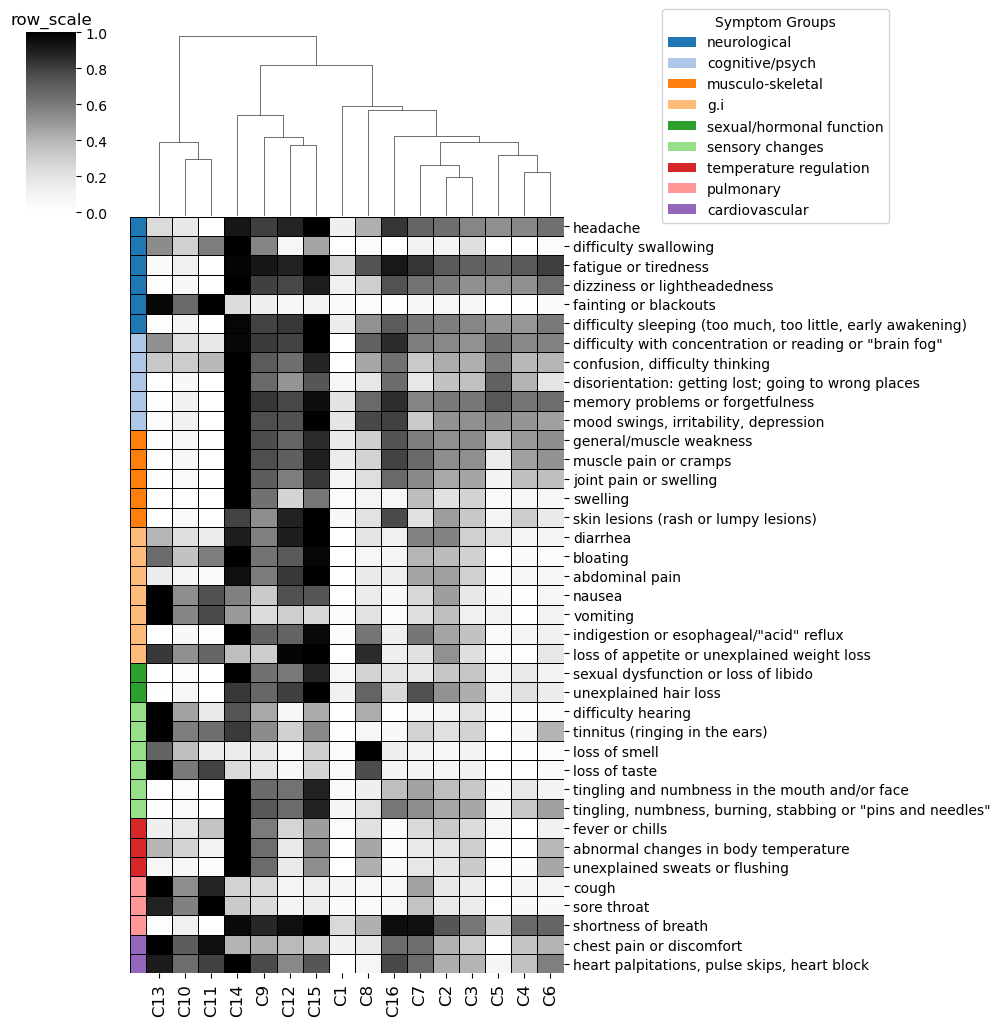

In [72]:
ax = sns.clustermap(cluster_by_symptom, vmin = 0, col_cluster = True, row_cluster = False, row_colors = symptoms_ordered_colors, 
                    standard_scale = 0, 
                    xticklabels = 1, yticklabels = 1, cbar_kws = {'label': ''}, 
                    cmap = "Greys", linecolor = "black", linewidth = 0.5, square = True)
plt.legend(handles, color_mapping, title='Symptom Groups', facecolor = "white", 
           bbox_to_anchor=(0.89, 1.01), bbox_transform=plt.gcf().transFigure)
a = plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90, size = 12)
a = plt.title("row_scale") # 0
print(f'{file.split("Subphenotyping-for-PASC_test/")[-1]}')

In [73]:
# printing top organ systems in cluster order
for key in [13, 10, 11, 14, 9, 12, 15, 1, 8, 16, 7, 2, 3, 5, 4, 6]: 
    print(key, cluster_toporgans_dict[key])

13 ['g.i', 'neurological', 'sensory changes']
10 ['neurological', 'pulmonary', 'sensory changes']
11 ['g.i', 'neurological', 'pulmonary']
14 ['musculo-skeletal', 'neurological', 'sexual/hormonal function']
9 ['musculo-skeletal', 'neurological', 'temperature regulation']
12 ['g.i', 'musculo-skeletal', 'sexual/hormonal function']
15 ['musculo-skeletal', 'sensory changes', 'sexual/hormonal function']
1 ['neurological', 'pulmonary', 'sensory changes']
8 ['g.i', 'sensory changes', 'sexual/hormonal function']
16 ['cognitive/psych', 'musculo-skeletal', 'sensory changes']
7 ['g.i', 'musculo-skeletal', 'sexual/hormonal function']
2 ['g.i', 'musculo-skeletal', 'sexual/hormonal function']
3 ['musculo-skeletal', 'sexual/hormonal function', 'temperature regulation']
5 ['cognitive/psych', 'neurological']
4 ['cognitive/psych', 'neurological', 'pulmonary']
6 ['neurological', 'sensory changes', 'temperature regulation']


In [74]:
endo_dict = {1:0, 2:1, 3:1, 4:2, 5:2, 6:2, 7:1, 8:3, 9:4, 10:5, 11:5, 12:4, 13:5, 14:4, 15:4, 16:6} # sinai_emory_n675

In [75]:
severity

,level_0,index,sum,cluster,color
0,0,C1,2.693430,1,green
1,4,C5,7.531502,5,yellow
2,3,C4,9.349821,4,yellow
3,9,C10,10.143111,10,yellow
4,10,C11,11.000245,11,yellow
5,5,C6,11.455695,6,yellow
6,7,C8,13.575812,8,yellow
7,2,C3,13.622445,3,yellow
8,12,C13,14.941260,13,yellow
9,15,C16,15.158388,16,yellow


# Final cluster assignments

In [76]:
surveys = pd.read_csv("data_cleaned/emory_and_sinai_n675.csv")
patients = surveys.copy()
patients["cluster"] = clusters
dictionary = dict(zip(severity["cluster"], severity["color"]))
patients["severity"] = [dictionary[val] for val in patients["cluster"]]
dictionary = {"green": "mild", "yellow": "moderate", "red": "severe"}
patients["severity"] = [dictionary[val] for val in patients["severity"]]
dictionary = dict(zip(severity["cluster"], severity["sum"]))
patients["severity_score"] = [dictionary[val] for val in patients["cluster"]]
patients["top6symptoms"] = [cluster_topsymptoms_dict[val] for val in patients["cluster"]]
patients["top3organs"] = [cluster_toporgans_dict[val] for val in patients["cluster"]]
patients["endotype"] = ["E" + str(endo_dict[val]) for val in patients["cluster"]]
columns = ["record_id", 'sex', 'cluster', 'endotype', 'severity', 'severity_score', 'top6symptoms', 'top3organs']
#, 'auto', 'cancer', 'diab', 'heart', 'hiv', 'hosp', 'hyper', 'icu', 'kidney', 'lung', 'oxy', 'smk', 'student', 'venti', 'day', 'abdom', 'back', 'balan', 'chest', 'chills', 'concen', 'const', 'cough', 'cramps', 'diarr', 'dizz', 'faint', 'fatig', 'fever', 'head                                                                                  .', 'heartrace', 'loss', 'muscle', 'nausea', 'numb', 'odor', 'pain', 'painsex', 'rash', 'runny', 'short', 'sleep', 'smell', 'sore', 'temp', 'vision', 'vomit']
patients = patients[columns]
patients.columns = ["Subject_ID", "Sex", "Cluster_ID", "Endotype_ID (defined by organ systems involved)", 
                    "Severity_Group (predicted by ML)", "severity_score", "Top6_signature_symptoms", "Top3_organ_systems"]
# patients.to_csv(f"cluster_assignments_sinai_emory_n{n}_{number_of_topics}topics_{n_clusters}clusters_v1.csv", index = False)
patients

,Subject_ID,Sex,Cluster_ID,Endotype_ID (defined by organ systems involved),Severity_Group (predicted by ML),severity_score,Top6_signature_symptoms,Top3_organ_systems
0,9,F,11,E5,moderate,11.000245,"[fainting or blackouts, sore throat, cough, vo...","[g.i, neurological, pulmonary]"
1,11,M,1,E0,mild,2.693430,"[shortness of breath, cough, fatigue or tiredn...","[neurological, pulmonary, sensory changes]"
2,12,M,1,E0,mild,2.693430,"[shortness of breath, cough, fatigue or tiredn...","[neurological, pulmonary, sensory changes]"
3,13,F,10,E5,moderate,10.143111,"[fainting or blackouts, sore throat, loss of t...","[neurological, pulmonary, sensory changes]"
4,14,F,11,E5,moderate,11.000245,"[fainting or blackouts, sore throat, cough, vo...","[g.i, neurological, pulmonary]"
...,...,...,...,...,...,...,...,...
670,3556,F,1,E0,mild,2.693430,"[shortness of breath, cough, fatigue or tiredn...","[neurological, pulmonary, sensory changes]"
671,3579 3582,F,16,E6,moderate,15.158388,"[skin lesions (rash or lumpy lesions), disorie...","[cognitive/psych, musculo-skeletal, sensory ch..."
672,3580,F,1,E0,mild,2.693430,"[shortness of breath, cough, fatigue or tiredn...","[neurological, pulmonary, sensory changes]"
673,3591,F,2,E1,moderate,15.267783,"[diarrhea, abdominal pain, skin lesions (rash ...","[g.i, musculo-skeletal, sexual/hormonal function]"
